In [1]:
import numpy as np
import h5py as h5
import numpy as np
import sys,os
import readgadget
import MAS_library as MASL
import pickle as pk
import readfof
import matplotlib
import h5py as h5
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')
%matplotlib inline


In [2]:
params_all = np.loadtxt('/projects/bdne/spandey3/GOTHAM/prep_data/camels_tng_LH_params.txt', usecols=range(1, 7))
# params.shape
# params[:,5]




In [3]:
norm_delta = 100,
norm_vel = 1000,
BoxSize = 25.
grid = 8
grid_sbox = 32
npart_test = 128**3
nMax_h = 20
nvocab = 64
nrand_sel_box = 16
Mstar_cut = 8

def get_data(isim_fid, subsamp_ds=1):

    params = params_all[isim_fid][None,:]

    sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
    savefname = f'{sdir}/subhalo_density3Dgrid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_lgMmin_{Mstar_cut}.pkl'

    saved = pk.load(open(savefname, 'rb'))
    dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed = saved['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed']
    Nhalos_truth_flatten = saved['Nhalos_truth_flatten']
    delta_box_all_squeezed = saved['delta_box_all_squeezed']
    rand_sel = saved['rand_sel']

    if subsamp_ds>1:
        nsel = int(len(rand_sel)/subsamp_ds)
        dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed = dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[:nsel,...]
        Nhalos_truth_flatten = Nhalos_truth_flatten[:nsel,...]
        delta_box_all_squeezed = delta_box_all_squeezed[:nsel,...]
        rand_sel = rand_sel[:nsel]

    params_repeated = np.repeat(params, len(rand_sel), axis=0)
    return params_repeated, delta_box_all_squeezed, Nhalos_truth_flatten[:,None], dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed, rand_sel[:,None]




In [4]:
from tqdm import tqdm
params_repeated_all = []
delta_box_all_squeezed_all = []
Nhalos_truth_flatten_all = []
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all = []
rand_sel_all = []
nsims_all = 1000
subsamp_ds = 2
for ji in tqdm(range(nsims_all)):
    params_repeated, delta_box_all_squeezed, Nhalos_truth_flatten, dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed, rand_sel = get_data(ji, subsamp_ds=subsamp_ds)
    params_repeated_all.append(params_repeated)
    delta_box_all_squeezed_all.append(delta_box_all_squeezed)
    Nhalos_truth_flatten_all.append(Nhalos_truth_flatten)
    dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all.append(dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed)
    rand_sel_all.append(rand_sel)





  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [04:08<00:00,  4.03it/s]


In [5]:
params_repeated_all = np.concatenate(params_repeated_all, axis=0)
delta_box_all_squeezed_all = np.concatenate(delta_box_all_squeezed_all, axis=0)
Nhalos_truth_flatten_all = np.concatenate(Nhalos_truth_flatten_all, axis=0)
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all = np.concatenate(dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all, axis=0)
rand_sel_all = np.concatenate(rand_sel_all, axis=0)




In [6]:

isim_fid = 0
sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
savefname = f'{sdir}/subhalo_density3Dgrid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_lgMmin_{Mstar_cut}.pkl'

saved = pk.load(open(savefname, 'rb'))
nvocab_total = saved['nvocab_total']
grid = saved['grid_sbox']
start_token = saved['start_token']
pad_token = saved['pad_token']
end_token = saved['end_token']
space_token = saved['space_token']
max_sentence_length = saved['max_sentence_length']
# saved = {'dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed':dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed.astype(np.int16)[rand_sel,...],
#         # 'dfhalo_ngp_wxyzM': dfhalo_ngp_wxyzM.astype(np.float32),
#         'Nhalos_truth_flatten': Nhalos_truth_flatten.astype(np.int16)[rand_sel],
#         'delta_box_all_squeezed': delta_box_all_squeezed.astype(np.float32)[rand_sel, ...],
#         'rand_sel': rand_sel,
#         'nvocab_total': nvocab + 3,
#         'max_sentence_length': max_sentence_length,
#         'grid': grid,
#         'grid_sbox': grid_sbox,
#         'nMax_h': nMax_h,
#         'BoxSize': BoxSize,
#         'prop_min': prop_min,
#         'prop_max': prop_max,
#         'xmin': xmin,
#         'norm_delta': norm_delta,
#         'norm_vel': norm_vel,
#         'start_token': start_token,
#         'pad_token': pad_token,
#         'end_token': end_token,
#         'space_token': space_token
#         }



In [7]:
# save as hdf5 file
sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
savefname = f'{sdir}/ALL_data_nspersim_subhalo_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_nvocab{nvocab}_lgMmin_{Mstar_cut}.h5'
with h5.File(savefname, 'w') as f:
    f.create_dataset('params_repeated_all', data=params_repeated_all)
    f.create_dataset('delta_box_all_squeezed_all', data=delta_box_all_squeezed_all)
    f.create_dataset('Nhalos_truth_flatten_all', data=Nhalos_truth_flatten_all)
    f.create_dataset('dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all', data=dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all)
    f.create_dataset('rand_sel_all', data=rand_sel_all)
    f.create_dataset('nvocab_total', data=nvocab_total)
    f.create_dataset('grid', data=grid)
    f.create_dataset('start_token', data=start_token)
    f.create_dataset('pad_token', data=pad_token)
    f.create_dataset('end_token', data=end_token)
    f.create_dataset('space_token', data=space_token)
    f.create_dataset('max_sentence_length', data=max_sentence_length)
    f.close()





In [22]:
norm_delta = 100,
norm_vel = 1000,
BoxSize = 25.
grid = 8
grid_sbox = 32
npart_test = 128**3
nMax_h = 20
nvocab = 64
nrand_sel_box = 16
Mstar_cut = 8
subsamp_ds = 8
sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
savefname = f'{sdir}/ALL_data_nspersim_subhalo_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_nvocab{nvocab}_lgMmin_{Mstar_cut}.h5'
with h5.File(savefname, 'r') as f:
    params_repeated_all = f['params_repeated_all'][()]
    delta_box_all_squeezed_all = f['delta_box_all_squeezed_all'][()]
    dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all = f['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all'][()]
    nvocab_total = f['nvocab_total'][()]
    grid_size = f['grid'][()]
    start_token = f['start_token'][()]
    pad_token = f['pad_token'][()]
    end_token = f['end_token'][()]
    max_sentence_length = f['max_sentence_length'][()]    
    f.close()

    

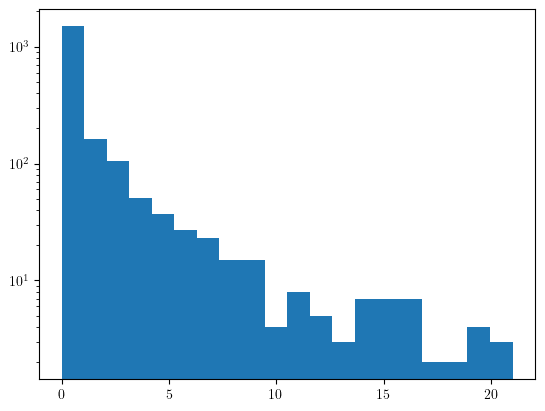

In [23]:
# params_repeated_all.shape
# delta_box_all_squeezed_all.shape
# dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all
pl.figure()
_ = pl.hist(Nhalos_truth_flatten_all, bins=20, range=(0, 21))
pl.yscale('log')
pl.show()


In [13]:
Nhalos_truth_flatten_all


array([[1],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], dtype=int16)